# Data Exploration -- Shichen Active Matter Dataset
*2023 May 15*

In this notebook I will be loading, visualizing, and performing preliminary 
analysis on an active matter dataset that Shichen kindly provided for this
project. 


The following items are of particular interest: 
 - Magnitude of differences between frames. 
 - Data ranges, potential normalization strategies. 
 - Variability in qualitative behaviour. 
 - Amenability to continuum modelling vs. particle-based TCA systems.


A few next steps to keep in mind include: 
 - Make a next-frame-prediction image-to-image deep learning model (simple baseline). 
 - Make an NCA-style next frame prediction iterated model $\to$ get a sense of the utility of BPTT. 
 - Make a TCA-style particle system model $\to$ get a sense of the applicability of TCA to the data. 

In [1]:
## Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# opencv 
import cv2

In [2]:
## Constants
DATA_DIR = "../datasets/1229_phase/"

In [13]:
## Acquiring the data -> RAM. 

# Let's get a list of all AVI files in DATA_DIR: 
avi_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".avi")]

# Now let's load them into RAM with cv2
# We'll use a dictionary to store them, with the filename as the key
# and the video as the value.
videos = []
for avi in avi_files:
    video_in = cv2.VideoCapture(DATA_DIR + avi)
    # converting video_in to numpy array 
    videos.append((avi, video_in))



In [14]:
videos[0][1]

< cv2.VideoCapture 0x2845091b0>

## 1: Visualizing some Frames

Let's visualize the first few frames of the first video. 

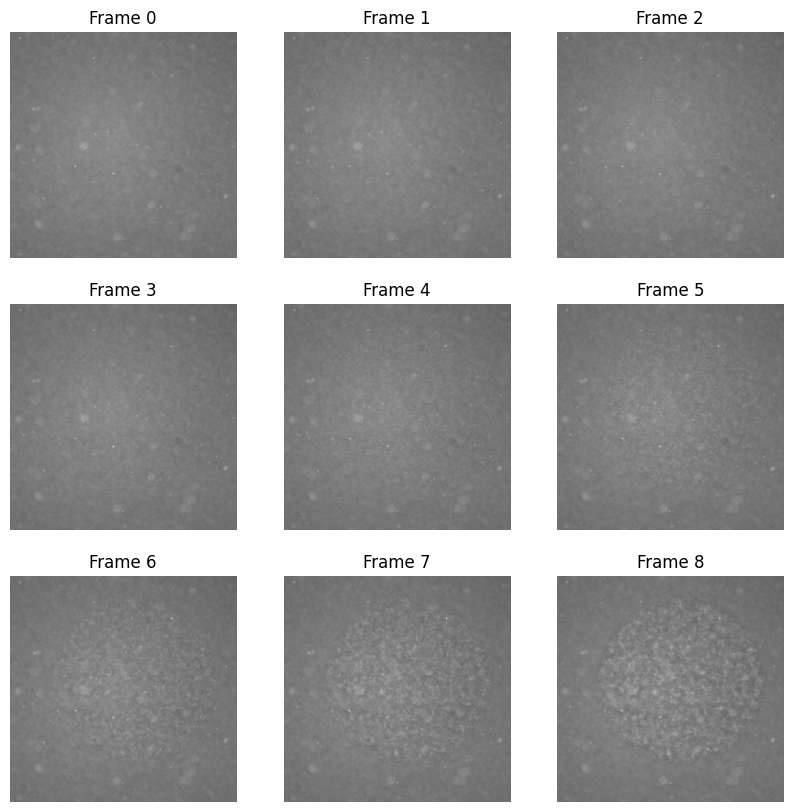

In [15]:
# Make a 3x3 grid of plots, each showing a frame from the first video 
# in the list
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(videos[0][1].read()[1])
    ax.set_title("Frame {}".format(i))
    ax.axis("off")

In [16]:
print("Total frames in video 1: ", videos[0][1].get(cv2.CAP_PROP_FRAME_COUNT))

Total frames in video 1:  599.0


Text(0.5, 0.98, '155min_MT_circle_1uL_2.avi')

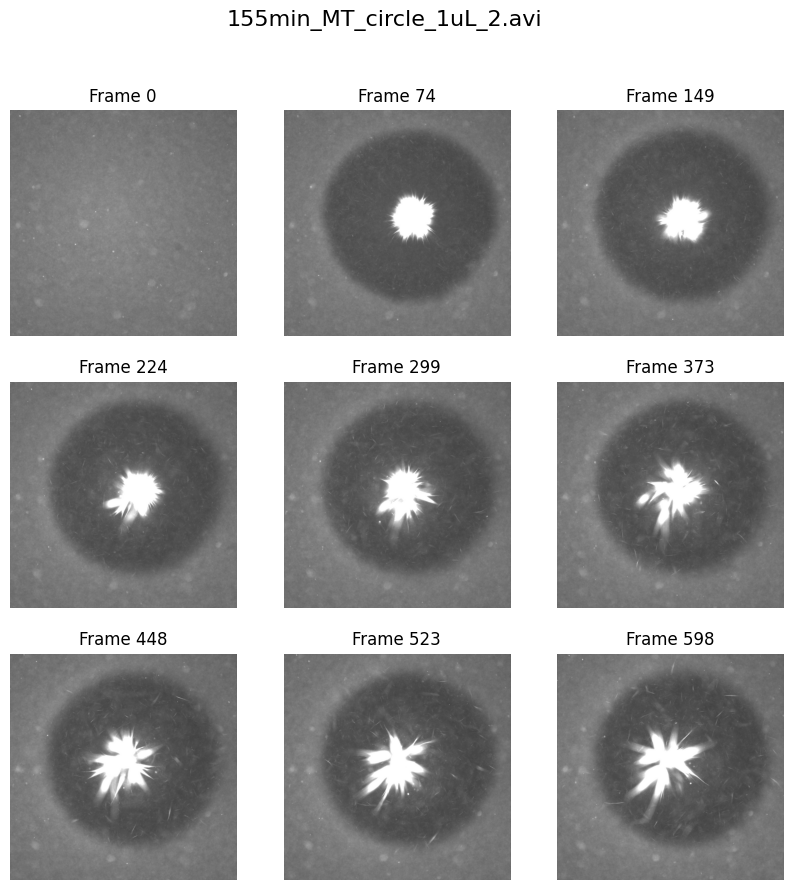

In [18]:
## Let's visualize 9 evently spaced frames from the first video, ending with the 
# last frame. 
num_frames = int(videos[0][1].get(cv2.CAP_PROP_FRAME_COUNT))
frames = np.linspace(0, num_frames - 1, 9).astype(int)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in zip(frames, axes.flatten()):
    videos[0][1].set(cv2.CAP_PROP_POS_FRAMES, i)
    ax.imshow(videos[0][1].read()[1])
    ax.set_title("Frame {}".format(i))
    ax.axis("off")
# adding supertitle with video name
fig.suptitle(videos[0][0], fontsize=16)

## 2: Computing Statistics on Data Values over Training

Let's see what the means, standard deviations, min, and max pixel values look 
like for these frames. 

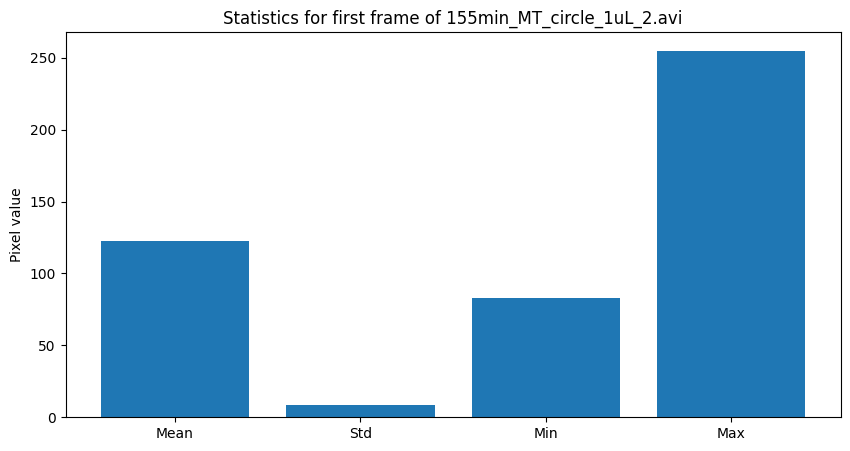

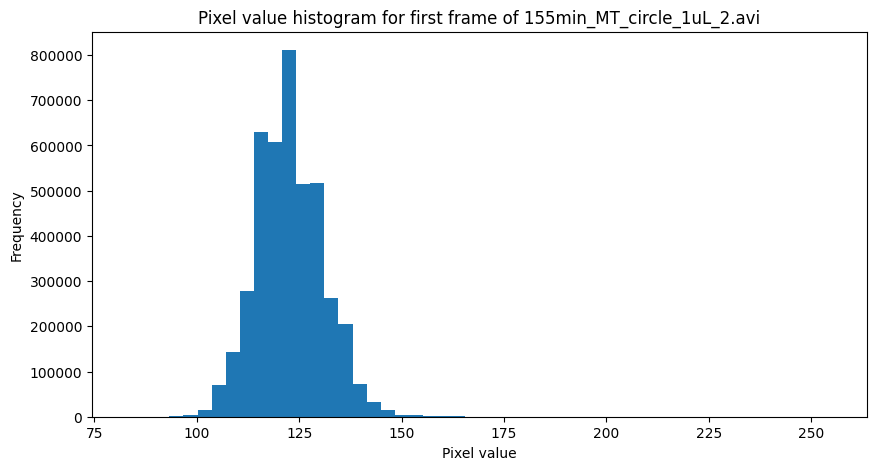

In [21]:
## Let's make a bar plot with the means, standard deviations, min, and max for 
# the first frame of the first video. 
# Note that these are greyscale videos, so we only need to care about the first 
# channel. 

# Let's get the first frame of the first video
videos[0][1].set(cv2.CAP_PROP_POS_FRAMES, 0)
frame = videos[0][1].read()[1][:, :, 0]

# Now let's get the mean, standard deviation, min, and max
mean = frame.mean()
std = frame.std()
min_ = frame.min()
max_ = frame.max()

# And plot them
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(["Mean", "Std", "Min", "Max"], [mean, std, min_, max_])
ax.set_title("Statistics for first frame of {}".format(videos[0][0]))
ax.set_ylabel("Pixel value")
plt.show()

## Let's make a histogram of the pixel values for the first frame of the first
# video.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(frame.flatten(), bins=50)
ax.set_title("Pixel value histogram for first frame of {}".format(videos[0][0]))
ax.set_xlabel("Pixel value")
ax.set_ylabel("Frequency")
plt.show()



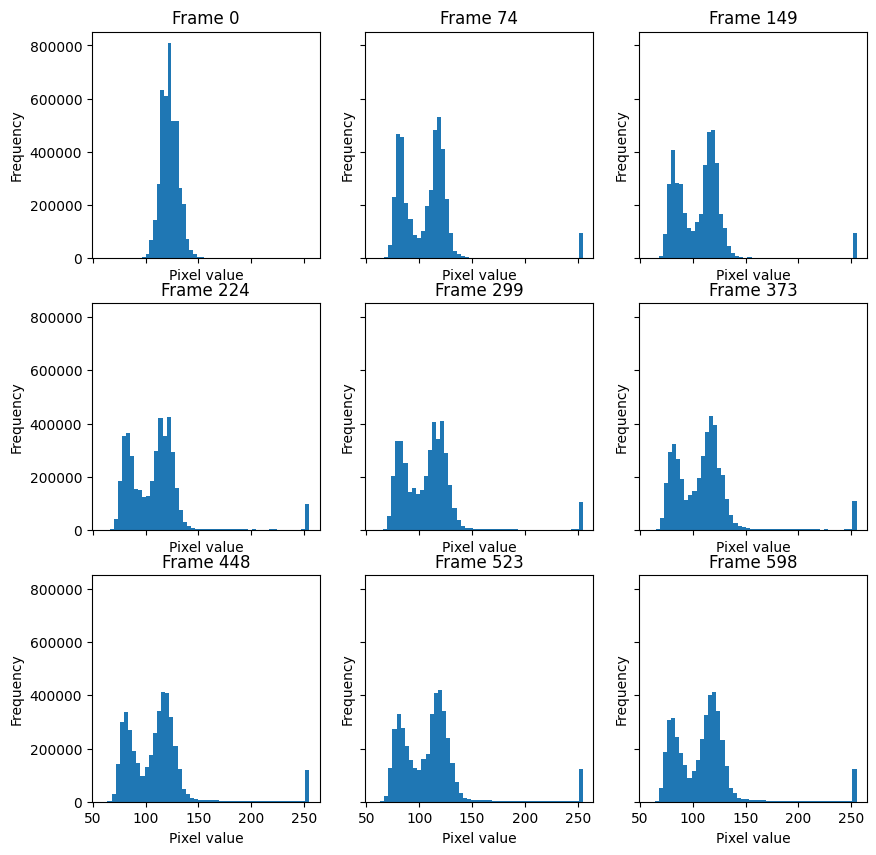

In [23]:
## Now let's make a 3x3 grid of histograms from the first frame to the last frame 
# of the first video: 
fig, axes = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True)

for i, ax in zip(frames, axes.flatten()):
    videos[0][1].set(cv2.CAP_PROP_POS_FRAMES, i)
    frame = videos[0][1].read()[1][:, :, 0]
    ax.hist(frame.flatten(), bins=50)
    ax.set_title("Frame {}".format(i))
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Frequency")